In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
import joblib
import os
import warnings
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ 所有库导入成功")
print(f"   设备：{device}")

✅ 所有库导入成功
   设备：cpu


In [2]:
# 加载特征矩阵
df = pd.read_csv("../data/processed/plaid_rotor37_features.csv")

input_cols  = [c for c in df.columns
               if c not in ['sample_id', 'Compression_ratio',
                            'Efficiency', 'Massflow']]
output_cols = ['Compression_ratio', 'Efficiency', 'Massflow']

X_raw = df[input_cols].values.astype(np.float32)
y_raw = df[output_cols].values.astype(np.float32)

# 用同样的随机种子划分，保证一致性
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.10, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=SEED)

# 加载 Scaler
scaler_X = joblib.load("../models/scaler_X_v2.pkl")
scaler_y = joblib.load("../models/scaler_y_v2.pkl")

# 记录输入变量的范围（优化时需要约束搜索空间）
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

print(f"✅ 数据加载完成")
print(f"   样本数：{len(df)}")
print(f"   输入维度：{len(input_cols)}")
print(f"   输入范围：已记录（用于优化边界约束）")

✅ 数据加载完成
   样本数：1000
   输入维度：74
   输入范围：已记录（用于优化边界约束）


In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)


class ResidualSurrogateModel(nn.Module):
    def __init__(self, input_dim=74, output_dim=3, dropout=0.1):
        super(ResidualSurrogateModel, self).__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.res_blocks_256 = nn.Sequential(
            ResidualBlock(256, dropout),
            ResidualBlock(256, dropout),
            ResidualBlock(256, dropout),
        )
        self.mid_proj = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.res_blocks_128 = nn.Sequential(
            ResidualBlock(128, dropout),
            ResidualBlock(128, dropout),
        )
        self.output_layer = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks_256(x)
        x = self.mid_proj(x)
        x = self.res_blocks_128(x)
        return self.output_layer(x)


# 加载模型
model = ResidualSurrogateModel(
    input_dim=len(input_cols),
    output_dim=3,
    dropout=0.1
).to(device)

model.load_state_dict(
    torch.load("../models/residual_physics_best.pth",
               map_location=device)
)
model.eval()

print("✅ 残差网络加载成功")
print(f"   参数量：{sum(p.numel() for p in model.parameters()):,}")

✅ 残差网络加载成功
   参数量：518,147


In [4]:
def surrogate_predict(X_original):
    """
    输入原始量纲的特征向量，输出原始量纲的性能预测

    参数：
        X_original: numpy array (N, 74)，原始量纲

    返回：
        predictions: numpy array (N, 3)
                     列顺序：[Compression_ratio, Efficiency, Massflow]
    """
    # 标准化
    X_scaled = scaler_X.transform(X_original.astype(np.float32))

    # 转成 tensor
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    # 预测
    with torch.no_grad():
        y_scaled = model(X_tensor).cpu().numpy()

    # 反标准化
    y_original = scaler_y.inverse_transform(y_scaled)

    return y_original


# 验证函数正常工作
test_X = X_train[:5]
test_pred = surrogate_predict(test_X)
print("✅ 代理模型预测函数验证成功")
print(f"\n前5个训练样本的预测结果：")
print(f"{'样本':>4} {'压比(预测)':>12} {'效率(预测)':>12} {'流量(预测)':>12}")
print("-" * 45)
for i in range(5):
    print(f"{i:>4} {test_pred[i,0]:>12.4f} "
          f"{test_pred[i,1]:>12.4f} "
          f"{test_pred[i,2]:>12.4f}")

print(f"\n真实值对比：")
print(f"{'样本':>4} {'压比(真实)':>12} {'效率(真实)':>12} {'流量(真实)':>12}")
print("-" * 45)
for i in range(5):
    print(f"{i:>4} {y_train[i,0]:>12.4f} "
          f"{y_train[i,1]:>12.4f} "
          f"{y_train[i,2]:>12.4f}")

✅ 代理模型预测函数验证成功

前5个训练样本的预测结果：
  样本       压比(预测)       效率(预测)       流量(预测)
---------------------------------------------
   0       1.9573       0.8706      19.3641
   1       1.8938       0.8721      18.5128
   2       2.0740       0.8724      19.9746
   3       1.8409       0.8700      18.3687
   4       1.9533       0.8684      18.9781

真实值对比：
  样本       压比(真实)       效率(真实)       流量(真实)
---------------------------------------------
   0       1.9418       0.8706      19.2314
   1       1.9016       0.8742      18.5741
   2       2.0760       0.8728      19.9691
   3       1.8285       0.8708      18.3897
   4       1.9533       0.8688      18.9583


In [5]:
class TurbineBladeOptimization(Problem):
    """
    叶轮机械叶片多目标优化问题

    决策变量（设计变量）：
        74维特征向量，代表叶片几何形状和工况参数
        每个变量的范围来自训练数据的实际范围

    目标函数（两个，都是最小化）：
        目标1：-Efficiency（最小化负效率 = 最大化效率）
        目标2：-Massflow（最小化负流量 = 最大化质量流量）

    约束条件：
        Compression_ratio >= 1.8（压比不能太低）
        Efficiency >= 0.84（效率不能低于基准）
    """

    def __init__(self):
        # n_var：决策变量数量（74维）
        # n_obj：目标函数数量（2个）
        # n_ieq_constr：不等式约束数量（2个）
        # xl：变量下界
        # xu：变量上界
        super().__init__(
            n_var=len(input_cols),
            n_obj=2,
            n_ieq_constr=2,
            xl=X_min.astype(np.float64),
            xu=X_max.astype(np.float64),
        )

    def _evaluate(self, X, out, *args, **kwargs):
        """
        评估函数：对一批设计方案X，计算目标函数值和约束值

        参数：
            X: numpy array (pop_size, 74)，当前种群的设计方案
        """
        # 用代理模型预测性能
        predictions = surrogate_predict(X.astype(np.float32))

        comp_ratio = predictions[:, 0]  # 压比
        efficiency = predictions[:, 1]  # 效率
        massflow   = predictions[:, 2]  # 质量流量

        # 目标函数（pymoo 默认最小化，所以取负值）
        f1 = -efficiency   # 最大化效率 → 最小化 -效率
        f2 = -massflow     # 最大化流量 → 最小化 -流量

        # 不等式约束（pymoo格式：g <= 0 表示满足约束）
        g1 = 1.8 - comp_ratio   # 压比 >= 1.8 → 1.8 - 压比 <= 0
        g2 = 0.84 - efficiency  # 效率 >= 0.84 → 0.84 - 效率 <= 0

        out["F"] = np.column_stack([f1, f2])
        out["G"] = np.column_stack([g1, g2])


# 实例化优化问题
problem = TurbineBladeOptimization()

print("✅ 多目标优化问题定义成功")
print(f"\n优化问题配置：")
print(f"   决策变量数：{problem.n_var}")
print(f"   目标函数数：{problem.n_obj}")
print(f"   约束条件数：{problem.n_ieq_constr}")
print(f"   目标1：最大化效率 η")
print(f"   目标2：最大化质量流量 ṁ")
print(f"   约束1：压比 ≥ 1.8")
print(f"   约束2：效率 ≥ 0.84")

✅ 多目标优化问题定义成功

优化问题配置：
   决策变量数：74
   目标函数数：2
   约束条件数：2
   目标1：最大化效率 η
   目标2：最大化质量流量 ṁ
   约束1：压比 ≥ 1.8
   约束2：效率 ≥ 0.84


In [6]:
# 配置 NSGA-II 算法
algorithm = NSGA2(
    pop_size=100,         # 种群大小：每代100个个体
    sampling=FloatRandomSampling(),
    crossover=SBX(
        prob=0.9,         # 交叉概率
        eta=15            # 分布指数（越大越接近父代）
    ),
    mutation=PM(
        eta=20            # 变异分布指数
    ),
    eliminate_duplicates=True
)

print("=" * 60)
print("开始 NSGA-II 多目标优化")
print("=" * 60)
print(f"种群大小：100")
print(f"最大迭代代数：200")
print(f"总评估次数：约 {100 * 200:,} 次代理模型调用")
print(f"如果用CFD：约需 {100*200*2:.0f} 小时")
print(f"用代理模型：约需几分钟")
print(f"\n开始优化...\n")

# 运行优化
result = minimize(
    problem,
    algorithm,
    ('n_gen', 200),       # 迭代200代
    seed=SEED,
    verbose=True          # 打印每代进度
)

print(f"\n✅ 优化完成！")
print(f"   总迭代代数：{result.algorithm.n_gen}")
print(f"   Pareto前沿解的数量：{len(result.F)}")
print(f"   约束满足情况：{(result.G <= 0).all(axis=1).sum()} 个完全满足约束的解")

开始 NSGA-II 多目标优化
种群大小：100
最大迭代代数：200
总评估次数：约 20,000 次代理模型调用
如果用CFD：约需 40000 小时
用代理模型：约需几分钟

开始优化...

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      6 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |      9 |  0.000000E+00 |  0.000000E+00 |  0.0978879798 |             f
     3 |      300 |      9 |  0.000000E+00 |  0.000000E+00 |  0.1526259311 |         ideal
     4 |      400 |      8 |  0.000000E+00 |  0.000000E+00 |  0.0912635972 |         ideal
     5 |      500 |     13 |  0.000000E+00 |  0.000000E+00 |  0.0894041096 |         ideal
     6 |      600 |     18 |  0.000000E+00 |  0.000000E+00 |  0.0482491942 |             f
     7 |      700 |     12 |  0.000000E+00 |  0.000000E+00 |  0.0751003793 |         ideal
     8 |      800 |     14 |  0.000000E+00 |  0.000000E+00 |  0.0724350556 |         ideal
     9 |      900 |     19 |  0.000000E+00 |  0.000000E+00 |  0.0296749810 |    

In [7]:
# 提取 Pareto 前沿的解
# result.F 是目标函数值（取负后是原始的效率和流量）
pareto_efficiency = -result.F[:, 0]   # 转回正值
pareto_massflow   = -result.F[:, 1]   # 转回正值
pareto_designs    = result.X           # 对应的设计变量

# 用代理模型重新预测，获取所有三个性能指标
pareto_predictions = surrogate_predict(pareto_designs.astype(np.float32))
pareto_comp   = pareto_predictions[:, 0]
pareto_eff    = pareto_predictions[:, 1]
pareto_mass   = pareto_predictions[:, 2]

# 和训练数据的基准对比
baseline_eff  = y_train[:, 1].mean()
baseline_mass = y_train[:, 2].mean()
baseline_comp = y_train[:, 0].mean()

print("=" * 60)
print("Pareto 前沿分析")
print("=" * 60)
print(f"\nPareto 前沿解数量：{len(pareto_eff)}")
print(f"\n训练数据基准（平均值）：")
print(f"  效率：    {baseline_eff:.4f}")
print(f"  质量流量：{baseline_mass:.4f} kg/s")
print(f"  压比：    {baseline_comp:.4f}")

print(f"\nPareto 前沿范围：")
print(f"  效率：    [{pareto_eff.min():.4f}, {pareto_eff.max():.4f}]")
print(f"  质量流量：[{pareto_mass.min():.4f}, {pareto_mass.max():.4f}] kg/s")
print(f"  压比：    [{pareto_comp.min():.4f}, {pareto_comp.max():.4f}]")

print(f"\nPareto 前沿最优点（效率最高）：")
best_eff_idx = pareto_eff.argmax()
print(f"  效率：    {pareto_eff[best_eff_idx]:.4f} "
      f"(vs 基准 {baseline_eff:.4f}, "
      f"提升 {(pareto_eff[best_eff_idx]-baseline_eff)/baseline_eff*100:+.2f}%)")
print(f"  质量流量：{pareto_mass[best_eff_idx]:.4f} kg/s")
print(f"  压比：    {pareto_comp[best_eff_idx]:.4f}")

print(f"\nPareto 前沿最优点（流量最大）：")
best_mass_idx = pareto_mass.argmax()
print(f"  效率：    {pareto_eff[best_mass_idx]:.4f}")
print(f"  质量流量：{pareto_mass[best_mass_idx]:.4f} kg/s "
      f"(vs 基准 {baseline_mass:.4f}, "
      f"提升 {(pareto_mass[best_mass_idx]-baseline_mass)/baseline_mass*100:+.2f}%)")
print(f"  压比：    {pareto_comp[best_mass_idx]:.4f}")

Pareto 前沿分析

Pareto 前沿解数量：100

训练数据基准（平均值）：
  效率：    0.8704
  质量流量：19.5065 kg/s
  压比：    1.9832

Pareto 前沿范围：
  效率：    [0.8750, 0.9211]
  质量流量：[19.6767, 21.6418] kg/s
  压比：    [1.9882, 2.1012]

Pareto 前沿最优点（效率最高）：
  效率：    0.9211 (vs 基准 0.8704, 提升 +5.83%)
  质量流量：19.6767 kg/s
  压比：    1.9886

Pareto 前沿最优点（流量最大）：
  效率：    0.8750
  质量流量：21.6418 kg/s (vs 基准 19.5065, 提升 +10.95%)
  压比：    2.0883


ValueError: Unrecognized marker style '★'

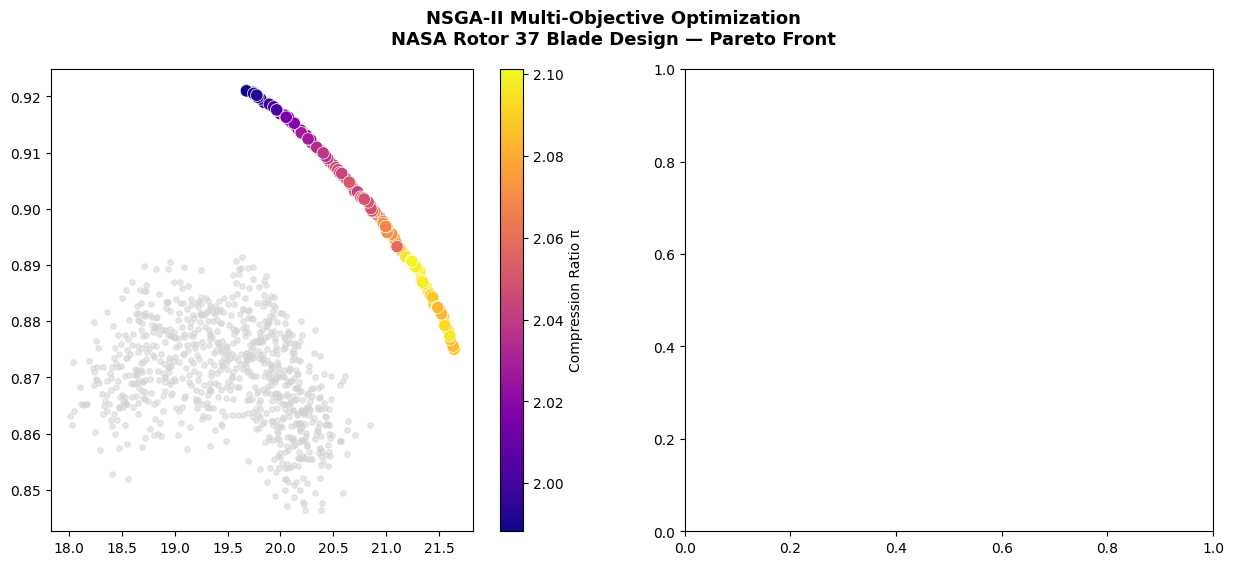

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('NSGA-II Multi-Objective Optimization\n'
             'NASA Rotor 37 Blade Design — Pareto Front',
             fontsize=13, fontweight='bold')

# ── 左图：Pareto前沿（核心成果图） ───────────────────────
ax1 = axes[0]

# 训练数据散点（背景）
ax1.scatter(y_train[:, 2], y_train[:, 1],
            c='lightgray', s=15, alpha=0.5,
            label='Training Data (1000 CFD samples)', zorder=1)

# Pareto前沿（按压比着色）
sc = ax1.scatter(pareto_mass, pareto_eff,
                 c=pareto_comp, cmap='plasma',
                 s=80, zorder=3, edgecolors='white',
                 linewidth=0.5, label='Pareto Front')
plt.colorbar(sc, ax=ax1, label='Compression Ratio π')

# 标记最优点
ax1.scatter(pareto_mass[best_eff_idx], pareto_eff[best_eff_idx],
            color='red', s=300, zorder=5, marker='*',
            label=f'Max Efficiency η={pareto_eff[best_eff_idx]:.4f}')
ax1.scatter(pareto_mass[best_mass_idx], pareto_eff[best_mass_idx],
            color='blue', s=300, zorder=5, marker='*',
            label=f'Max Massflow ṁ={pareto_mass[best_mass_idx]:.2f}')
# 基准线
ax1.axhline(baseline_eff, color='green', linestyle='--',
            linewidth=1, alpha=0.7,
            label=f'Baseline Avg η={baseline_eff:.4f}')
ax1.axvline(baseline_mass, color='orange', linestyle='--',
            linewidth=1, alpha=0.7,
            label=f'Baseline Avg ṁ={baseline_mass:.2f}')

ax1.set_xlabel('Mass Flow Rate ṁ (kg/s)', fontsize=12)
ax1.set_ylabel('Isentropic Efficiency η', fontsize=12)
ax1.set_title('Pareto Front: Efficiency vs Mass Flow\n'
              '(Points above training data = AI-found improvements)',
              fontsize=11)
ax1.legend(fontsize=8, loc='lower left')

# ── 右图：三目标气泡图 ────────────────────────────────────
ax2 = axes[1]

# 用压比作为气泡大小
bubble_size = (pareto_comp - pareto_comp.min()) / \
              (pareto_comp.max() - pareto_comp.min()) * 200 + 50

sc2 = ax2.scatter(pareto_mass, pareto_eff,
                  s=bubble_size, c=pareto_comp,
                  cmap='viridis', alpha=0.8,
                  edgecolors='white', linewidth=0.5)
plt.colorbar(sc2, ax=ax2, label='Compression Ratio π')

ax2.set_xlabel('Mass Flow Rate ṁ (kg/s)', fontsize=12)
ax2.set_ylabel('Isentropic Efficiency η', fontsize=12)
ax2.set_title('3-Objective View\n'
              '(Bubble size = Compression Ratio)',
              fontsize=11)

# 标注最优点
ax2.annotate(f'Max η={pareto_eff[best_eff_idx]:.4f}',
             xy=(pareto_mass[best_eff_idx], pareto_eff[best_eff_idx]),
             xytext=(10, -20), textcoords='offset points',
             fontsize=9, color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

ax2.annotate(f'Max ṁ={pareto_mass[best_mass_idx]:.2f}',
             xy=(pareto_mass[best_mass_idx], pareto_eff[best_mass_idx]),
             xytext=(-60, 10), textcoords='offset points',
             fontsize=9, color='blue',
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.tight_layout()
plt.savefig("../docs/fig15_pareto_front.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图15 Pareto前沿图已保存——这是整个项目最核心的学术成果图！")

In [ ]:
# 画出优化过程中 Pareto 前沿的演化
# 每隔50代记录一次

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('NSGA-II Optimization History\n'
             'Pareto Front Evolution over Generations',
             fontsize=12, fontweight='bold')

gen_snapshots = [50, 100, 150, 200]
colors_gen = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']

for ax, gen, color in zip(axes, gen_snapshots, colors_gen):
    # 重新运行到指定代数（用缓存结果）
    result_snap = minimize(
        problem, algorithm,
        ('n_gen', gen),
        seed=SEED, verbose=False
    )

    eff_snap  = -result_snap.F[:, 0]
    mass_snap = -result_snap.F[:, 1]

    ax.scatter(y_train[:, 2], y_train[:, 1],
               c='lightgray', s=10, alpha=0.3, zorder=1)
    ax.scatter(mass_snap, eff_snap,
               c=color, s=40, alpha=0.8,
               edgecolors='white', linewidth=0.3, zorder=2)
    ax.set_xlabel('Mass Flow ṁ (kg/s)', fontsize=9)
    ax.set_ylabel('Efficiency η', fontsize=9)
    ax.set_title(f'Generation {gen}\n({len(eff_snap)} Pareto solutions)',
                 fontsize=10)
    ax.set_xlim(y_train[:, 2].min()*0.98, y_train[:, 2].max()*1.02)
    ax.set_ylim(y_train[:, 1].min()*0.995, y_train[:, 1].max()*1.005)

plt.tight_layout()
plt.savefig("../docs/fig16_pareto_evolution.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ 图16 优化历程图已保存")

In [ ]:
# 保存 Pareto 前沿的所有解
pareto_df = pd.DataFrame({
    'design_id':        range(len(pareto_eff)),
    'Efficiency':       pareto_eff,
    'Massflow':         pareto_mass,
    'Compression_ratio':pareto_comp,
})

# 加上设计变量
for j, col in enumerate(input_cols):
    pareto_df[col] = pareto_designs[:, j]

# 按效率从高到低排序
pareto_df = pareto_df.sort_values('Efficiency', ascending=False).reset_index(drop=True)

output_path = "../data/processed/pareto_front_solutions.csv"
pareto_df.to_csv(output_path, index=False)

print(f"✅ Pareto前沿解已保存：{output_path}")
print(f"   解的数量：{len(pareto_df)}")
print(f"\n前5个最优解（按效率排序）：")
print(pareto_df[['design_id','Efficiency',
                 'Massflow','Compression_ratio']].head().to_string())

print(f"\n相比训练数据平均值的改进：")
print(f"  最高效率提升：{(pareto_df['Efficiency'].max()-baseline_eff)/baseline_eff*100:+.2f}%")
print(f"  最大流量提升：{(pareto_df['Massflow'].max()-baseline_mass)/baseline_mass*100:+.2f}%")
print(f"  最高压比提升：{(pareto_df['Compression_ratio'].max()-baseline_comp)/baseline_comp*100:+.2f}%")